# Spacehopper Gripper Data Evaluation\nThis notebook processes the raw ROS logs from the physical gripper tests on various rock surfaces. It trims the initial offsets, identifies the point of slippage (when Tangential Force Fx drops), and plots the Maximum Normal Force (Fz) vs Tangential Force prior to slippage. The calculated statistics are then used to evaluate the gripper's holding performance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
def plot_forces(df, cut_1=0, cut_2=None, avg_end=None, fx_threshold=1, fx_jump_threshold=4, offset_position='beginning', offset_length=10):
    """
    Plots the Tangential Force (Fx) and Normal Force (Fz) from the given DataFrame with offsets
    and within a specified range.

    Parameters:
    df (pd.DataFrame): The DataFrame containing force data with columns 'Fx' and 'Fz'.
    cut_1 (int): The starting index for the range of data to be plotted.
    cut_2 (int or None): The ending index for the range of data to be plotted. If None, plot till the end.
    avg_end (int or None): The ending index for calculating average values. If None, use cut_2.
    fx_threshold (float): The threshold below which to find the drop in Fx.
    fx_jump_threshold (float): The threshold above which to find a significant jump in Fx.
    offset_position (str): The position to calculate the offset ('beginning' or 'end').
    offset_length (int): The number of entries to consider for calculating the offset.

    Returns:
    None
    """
    if offset_position == 'beginning':
        # Calculate the offsets as the average of the first offset_length entries
        offset_x = df['Fx'][:offset_length].mean()
        offset_z = df['Fz'][:offset_length].mean()
    elif offset_position == 'end':
        # Calculate the offsets as the average of the last offset_length entries
        offset_x = df['Fx'][-offset_length:].mean()
        offset_z = df['Fz'][-offset_length:].mean()
    else:
        raise ValueError("Invalid offset_position. Choose either 'beginning' or 'end'.")

    # If avg_end is not provided, use cut_2
    avg_end = avg_end if avg_end is not None else cut_2

    # If avg_end is not None, calculate the length from cut_1 to avg_end
    if avg_end is not None and cut_1 is not None:
        length_cut_to_avg = avg_end - cut_1
        print(f"Length from cut_1 to avg_end: {length_cut_to_avg}")

    # Calculate average values of Fx and Fz in the defined averaging interval
    avg_fx = df[cut_1:avg_end]['Fx'].mean() - offset_x
    avg_fz = df[cut_1:avg_end]['Fz'].mean() - offset_z

    # Apply the cut range to the DataFrame
    df_cut = df[cut_1:cut_2].copy()
    
    # Find the maximum Fz and corresponding timestep
    max_fz = df_cut['Fz'].max() - offset_z
    max_fz_timestep = df_cut['Fz'].idxmax()

    # Find the timestep where Fx drops below the threshold
    fx_drop_timestep = df_cut[df_cut['Fx'] - offset_x < fx_threshold].index.min()
    
    # Find the point where Fx makes a significant jump
    fx_diff = df_cut['Fx'].diff().abs()
    fx_jump_timestep = fx_diff[fx_diff > fx_jump_threshold].index.min()

    # Print the average values and significant points
    print(f"Average Fx in the averaging interval [{cut_1}:{avg_end}]: {avg_fx}")
    print(f"Average Fz in the averaging interval [{cut_1}:{avg_end}]: {avg_fz}")
    print(f"Maximum Fz in the plotting interval [{cut_1}:{cut_2}]: {max_fz} at timestep {max_fz_timestep}")
    #print(f"Time step where Fx drops below {fx_threshold}: {fx_drop_timestep}")
    print(f"Time step where Fx makes a significant jump: {fx_jump_timestep} with a threshold of {fx_jump_threshold}")

    plt.figure(figsize=(10, 5))
    plt.plot(df_cut['Fx'] - offset_x, label='Tangential Force (Fx)', alpha=0.7)
    plt.plot(df_cut['Fz'] - offset_z, label='Normal Force (Fz)', alpha=0.7)
    plt.axvline(x=max_fz_timestep, color='r', linestyle='--', label='Max Fz', alpha=0.2)
    #plt.axvline(x=fx_drop_timestep, color='g', linestyle='--', label=f'Fx < {fx_threshold}', alpha=0.2)
    plt.axvline(x=fx_jump_timestep, color='b', linestyle='--', label=f'Fx Jump > {fx_jump_threshold}', alpha=0.2)
    plt.xlabel('Timesteps')
    plt.ylabel('Force (N)')
    plt.legend()
    plt.title('Tangential vs Normal Force (Offset Adjusted)')
    plt.grid()
    plt.show()

    # Apply the offsets to the cut DataFrame
    df_cut['Fx'] = df_cut['Fx'] - offset_x
    df_cut['Fz'] = df_cut['Fz'] - offset_z
    
    # Shift the index so it starts at 0 if cut_1 is not None
    if cut_1 is not None:
        df_cut.index = df_cut.index - cut_1

    # Return the modified DataFrame
    return df_cut, (length_cut_to_avg if avg_end is not None and cut_1 is not None else None)

Test 1

Length from cut_1 to avg_end: 1120
Average Fx in the averaging interval [1450:2570]: 1.2388233855097177
Average Fz in the averaging interval [1450:2570]: 1.9639021210584222
Maximum Fz in the plotting interval [1450:None]: 5.041910807291667 at timestep 2110
Time step where Fx makes a significant jump: nan with a threshold of 4


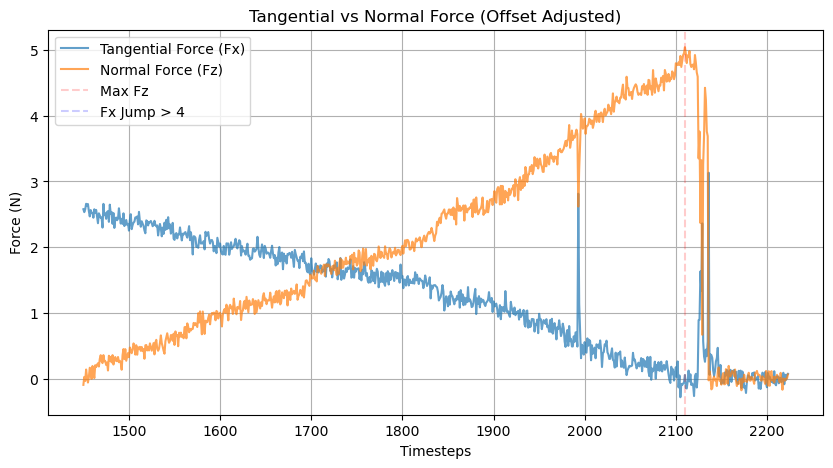

In [5]:
data = "../raw_data/Gripper Test Hook//Asphalt_Combined_5N//log_202406031452.csv"
df = pd.read_csv(data)
test_1, end_1 = plot_forces(df, cut_1=1450, cut_2=None, avg_end=2570, offset_position='end', offset_length=15)

Test 2

Average Fx in the averaging interval [1050:None]: 0.5096996305102394
Average Fz in the averaging interval [1050:None]: 1.2607738385881697
Maximum Fz in the plotting interval [1050:None]: 3.0290771484375 at timestep 1590
Time step where Fx makes a significant jump: nan with a threshold of 4


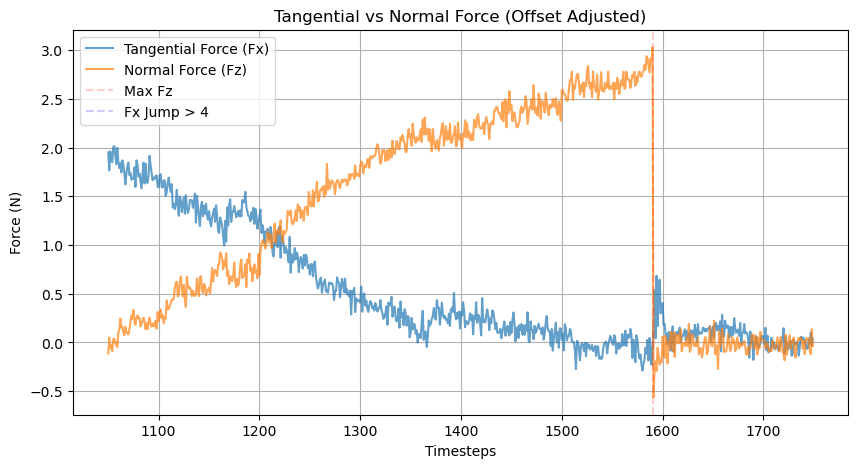

In [9]:
data = "../raw_data/Gripper Test Hook//Asphalt_Combined_5N//log_202406031454.csv"
df = pd.read_csv(data)
df = df[:1750]
test_1, end_1 = plot_forces(df, cut_1=1050, cut_2=None, avg_end=None, offset_position='end', offset_length=15)

Test 3 

Average Fx in the averaging interval [1250:None]: -0.004940714930543849
Average Fz in the averaging interval [1250:None]: 2.9146356160884643
Maximum Fz in the plotting interval [1250:None]: 6.032743326822916 at timestep 2331
Time step where Fx makes a significant jump: nan with a threshold of 4


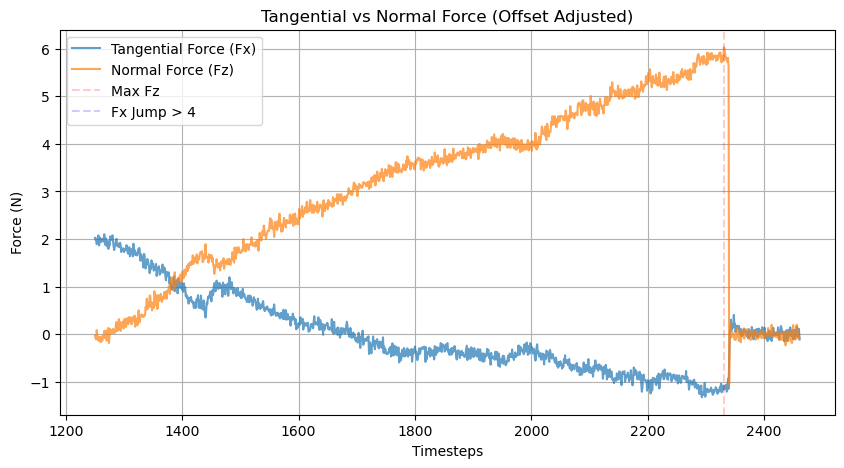

In [11]:
data = "../raw_data/Gripper Test Hook//Asphalt_Combined_5N//log_202406031456.csv"
df = pd.read_csv(data)
test_1, end_1 = plot_forces(df, cut_1=1250, cut_2=None, avg_end=None, offset_position='end', offset_length=15)